In [1]:
import pandas as pd  # Work with spreadsheet-like tables
import numpy as np  # Do math with arrays and random numbers
import seaborn as sns  # Make nice statistical plots
import matplotlib.pyplot as plt  # Basic plotting tool
from sklearn.model_selection import train_test_split  # Split data into train and test parts
from sklearn.linear_model import LinearRegression  # Simple math model that draws a best-fit line
from sklearn.metrics import r2_score  # Score that tells how well the line fits the data

import warnings  # Control warning messages
warnings.filterwarnings('ignore')  # Hide non-critical warnings to keep output clean

np.random.seed(42)  # Make random numbers repeat the same way every run
data_size= 200  # Number of pretend shoppers we will create

temp = np.random.uniform(20, 40, data_size)  # Make random temperatures between 20 and 40
price = np.random.uniform(10, 25, data_size)  # Make random ice cream prices between 10 and 25
weekend = np.random.choice([0, 1], size=data_size, p=[0.7, 0.3])  # Randomly pick weekends (1) or weekdays (0), p = probabilities 

sales = 100 + (temp * 10) + (price * -8) + (weekend * 50) + np.random.normal(0, 15, data_size)  # Build sales with rules plus noise

# DataFrame oluşturma
df_multi = pd.DataFrame({  # Put all columns into one table
    'Temperature': temp,  # Column for temperature
    'Price': price,  # Column for price
    'Weekend': weekend,  # Column for weekend flag
    'Sales': sales  # Column for sales numbers
})

df_multi.head()  # Peek at the first few rows to see what the table looks like

,Temperature,Price,Weekend,Sales
0,27.490802,19.630475,0,209.910362
1,39.014286,11.262099,1,438.152973
2,34.639879,12.424431,0,345.397887
3,31.973170,23.478313,1,266.376559
4,23.120373,19.096436,0,170.127501


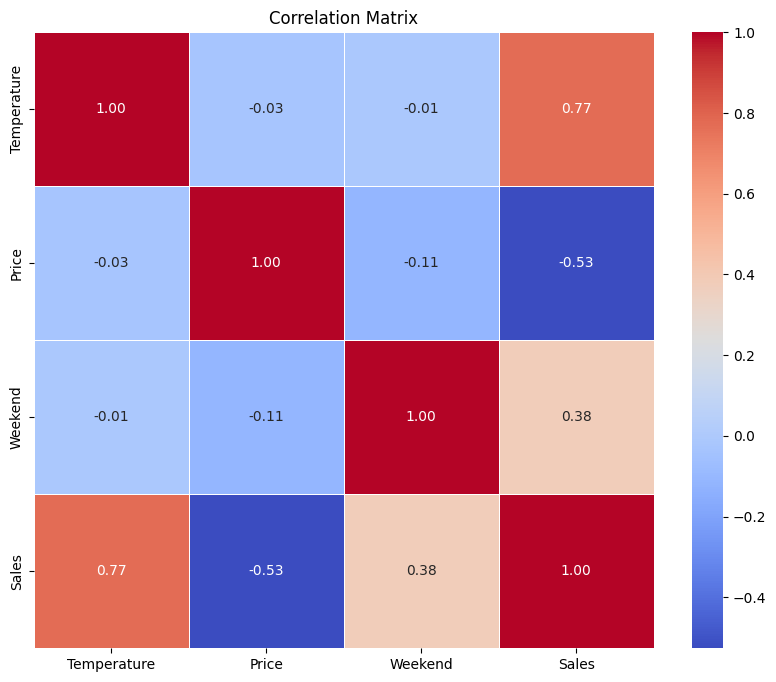

In [2]:
plt.figure(figsize=(10, 8))  # Make a larger blank canvas for the chart
corr_matrix = df_multi.corr()  # Calculate how each column relates to the others

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)  # Draw colored grid showing those relationships
plt.title('Correlation Matrix')  # Add a title so we know what the chart is
plt.show()  # Display the chart

In [3]:

X = df_multi[['Temperature', 'Price', 'Weekend']]  # Inputs: what we think affects sales

y = df_multi['Sales']  # Output we want to predict: sales numbers

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data: 80% train, 20% test

multi_model = LinearRegression()  # Create the multi-input line-fitting model
multi_model.fit(X_train, y_train)  # Teach the model using training data

print("Multiple Linear Regression Model Trained.")  # Let us know training finished

Multiple Linear Regression Model Trained.


In [4]:
coefficients = pd.DataFrame(multi_model.coef_, X.columns, columns=['Coefficient (Effect)'])  # Turn learned slopes into a tidy table
print(f"Intercept: {multi_model.intercept_:.2f}")  # Show base sales when all inputs are zero
print(coefficients)  # Show how each input pushes sales up or down

Intercept: 103.34
             Coefficient (Effect)
Temperature              9.879499
Price                   -8.166534
Weekend                 56.753973


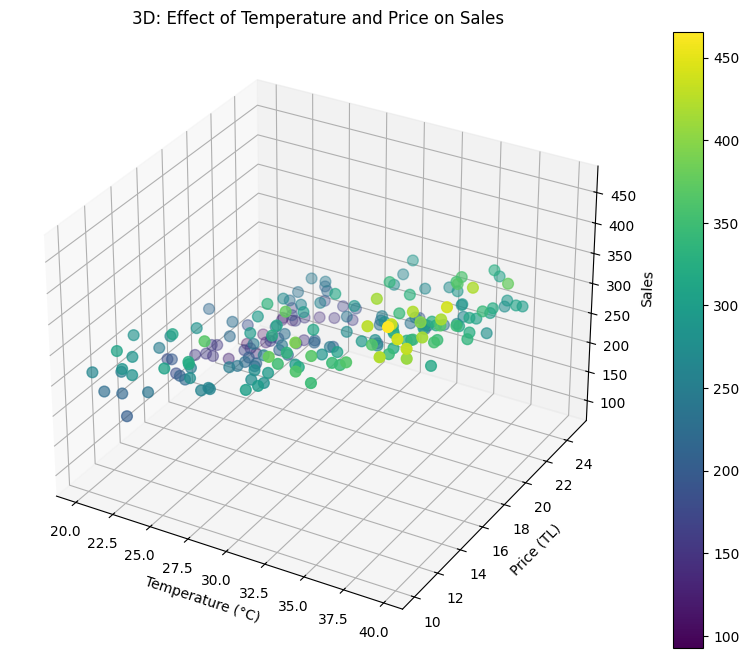

In [5]:
from mpl_toolkits.mplot3d import Axes3D  # Tool to draw 3D plots

fig = plt.figure(figsize=(12, 8))  # Create a wide figure for 3D view
ax = fig.add_subplot(111, projection='3d')  # Add a 3D plot area

img = ax.scatter(df_multi['Temperature'], df_multi['Price'], df_multi['Sales'], c=df_multi['Sales'], cmap='viridis', s=60)  # Plot points in 3D and color by sales

ax.set_xlabel('Temperature (°C)')  # Label x-axis
ax.set_ylabel('Price (TL)')  # Label y-axis
ax.set_zlabel('Sales')  # Label z-axis
plt.title('3D: Effect of Temperature and Price on Sales')  # Title describing the plot
plt.colorbar(img)  # Add color bar to show sales scale
plt.show()  # Display the 3D scatter plot

In [6]:
y_pred = multi_model.predict(X_test)  # Ask the model to guess sales for the test rows
r2 = r2_score(y_test, y_pred)  # Measure how well guesses match real values (closer to 1 is better)

print(f"Model R2 Score: {r2:.2f}")  # Show the fit score

Model R2 Score: 0.97


In [12]:
new_data = [[0, 200, 0]]  # Example: 20°C, price 20, weekend=1

prediction = multi_model.predict(new_data)  # Get the model's sales guess for that scenario

print(f"Scenario Prediction: {int(prediction[0])} ice creams will be sold.")  # Print the rounded guess

Scenario Prediction: -1529 ice creams will be sold.
